Epoch [100/1000], Loss: 7.3834
Epoch [200/1000], Loss: 1.8266
Epoch [300/1000], Loss: 0.4569
Epoch [400/1000], Loss: 0.1188
Epoch [500/1000], Loss: 0.0354
Epoch [600/1000], Loss: 0.0148
Epoch [700/1000], Loss: 0.0097
Epoch [800/1000], Loss: 0.0085
Epoch [900/1000], Loss: 0.0082
Epoch [1000/1000], Loss: 0.0081
linear.weight: [[9.96863]]
linear.bias: [0.9977536]


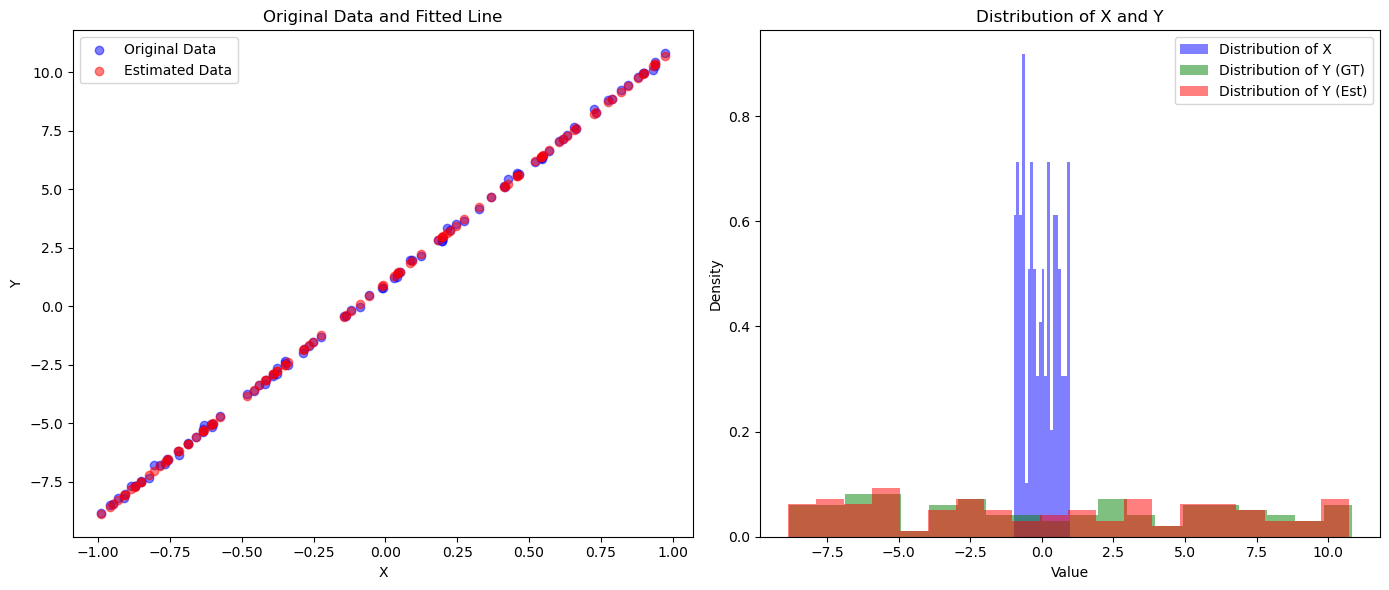

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Setting random seed for data generation
np.random.seed(42)
torch.manual_seed(42)

# Generating Uniform Variable data
X = np.random.uniform(low=-1, high=1, size=(100, 1)).astype(np.float32)
error = np.random.normal(loc=0, scale=0.1, size=(100, 1)).astype(np.float32)  # Adding noise
Y = 10 * X + 1 + error  # Generating Y variable

# Convert to Tensor
X_tensor = torch.from_numpy(X)
Y_tensor = torch.from_numpy(Y)

# Defining linear regression model class
class LinearRegressor(nn.Module):
    def __init__(self):
        super(LinearRegressor, self).__init__()
        self.linear = nn.Linear(1, 1)  # 1 input, 1 output

    def forward(self, x):
        return self.linear(x)

# Setting up model, loss function and optimizer
model = LinearRegressor()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training the model
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    
    # Passing input to the model
    optimizer.zero_grad()  # Reset gradients
    outputs = model(X_tensor)  # Calculate predictions
    loss = criterion(outputs, Y_tensor)  # Compute loss
    loss.backward()  # Compute gradients
    optimizer.step()  # Update model parameters
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Print the learned parameters of the model
for name, param in model.named_parameters():
    print(f'{name}: {param.data.numpy()}')

# Visualization of results
model.eval()
with torch.no_grad():
    predicted = model(X_tensor)

# Visualizing the distribution of X and Y
plt.figure(figsize=(14, 6))

# Original data and predicted results
plt.subplot(1, 2, 1)
plt.scatter(X, Y, label='Original Data', color='blue', alpha=0.5)
plt.scatter(X, predicted.numpy(), label='Estimated Data', color='red', alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original Data and Fitted Line')
plt.legend()

# Distribution of X and Y
plt.subplot(1, 2, 2)
plt.hist(X, bins=20, alpha=0.5, label='Distribution of X', color='blue', density=True)
plt.hist(Y, bins=20, alpha=0.5, label='Distribution of Y (GT)', color='green', density=True)
plt.hist(predicted.numpy(), bins=20, alpha=0.5, label='Distribution of Y (Est)', color='red', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of X and Y')
plt.legend()

plt.tight_layout()
plt.show()

Epoch [100/1000], Loss: 0.0791
Epoch [200/1000], Loss: 0.0992
Epoch [300/1000], Loss: 0.2325
Epoch [400/1000], Loss: 0.1683
Epoch [500/1000], Loss: 0.1246
Epoch [600/1000], Loss: 0.0952
Epoch [700/1000], Loss: 0.0767
Epoch [800/1000], Loss: 0.0695
Epoch [900/1000], Loss: 0.0630
Epoch [1000/1000], Loss: 0.0581
model.0.weight: [[ 0.8007845 ]
 [ 0.89270306]
 [-0.20942254]
 [ 0.98749316]
 [-0.21910357]
 [ 0.20179069]
 [-0.64782095]
 [ 0.56806713]
 [ 1.0422621 ]
 [-0.73362815]
 [ 0.8691962 ]
 [ 0.1871593 ]
 [ 0.7250565 ]
 [ 0.21135147]
 [ 0.4909855 ]
 [-0.16263847]
 [ 0.7809788 ]
 [ 0.14780891]
 [-0.58699495]
 [ 0.2548983 ]
 [-0.5546648 ]
 [-0.11727285]
 [-0.49826035]
 [ 0.66337097]
 [-0.82886976]
 [-0.48737285]
 [-0.27999413]
 [-0.6637706 ]
 [ 0.11434037]
 [-1.0236079 ]
 [ 0.89689565]
 [-0.9131749 ]
 [ 0.89933825]
 [ 0.16641915]
 [-0.32470453]
 [ 0.61794996]
 [ 0.15585077]
 [ 0.88102496]
 [ 0.10931969]
 [-0.31537318]
 [ 0.2750345 ]
 [-0.27117944]
 [ 0.42085755]
 [ 0.96025443]
 [ 0.57805955

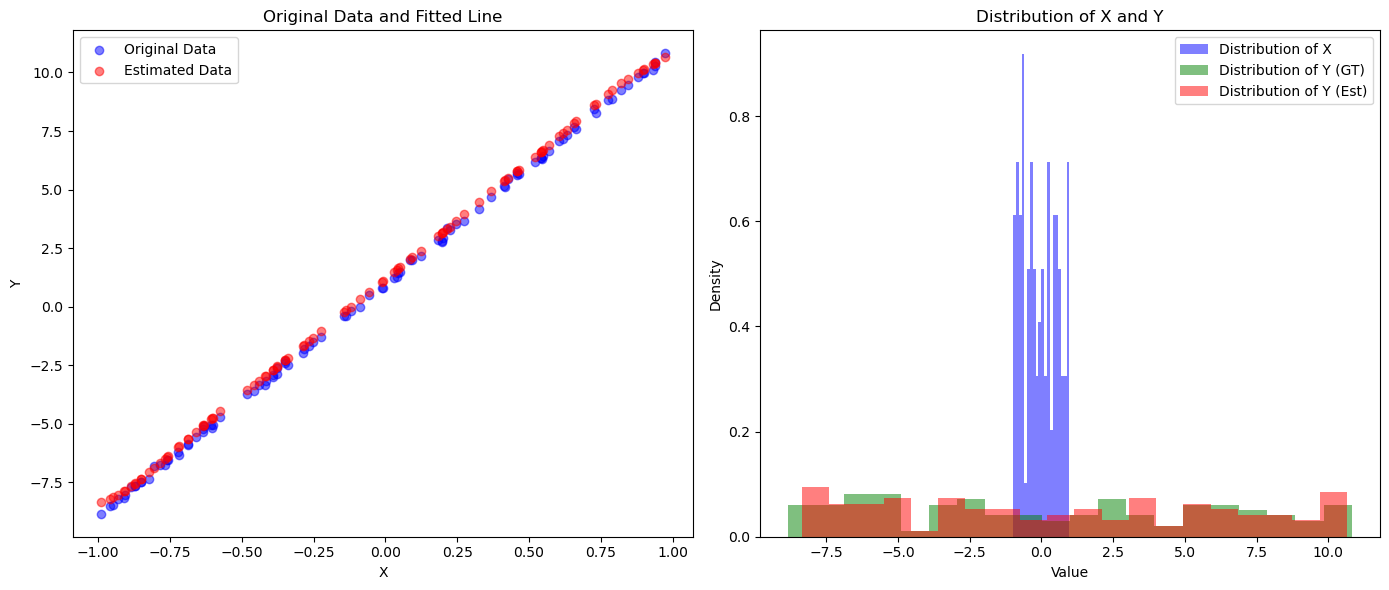

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Setting random seed for data generation
np.random.seed(42)
torch.manual_seed(42)

# Generating Uniform Variable data
X = np.random.uniform(low=-1, high=1, size=(100, 1)).astype(np.float32)
error = np.random.normal(loc=0, scale=0.1, size=(100, 1)).astype(np.float32)  # Adding noise
Y = 10 * X + 1 + error  # Generating Y variable

# Convert to Tensor
X_tensor = torch.from_numpy(X)
Y_tensor = torch.from_numpy(Y)

class DeepRegressor(nn.Module):
    def __init__(self):
        super(DeepRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),  # 1 input, 64 output
            nn.ReLU(),         # 활성화 함수
            nn.Linear(64, 128), # 64 input, 128 output
            nn.ReLU(),         # 활성화 함수
            nn.Linear(128, 64), # 128 input, 64 output
            nn.ReLU(),         # 활성화 함수
            nn.Linear(64, 1)   # 64 input, 1 output
        )

    def forward(self, x):
        return self.model(x)

# Setting up model, loss function and optimizer
model = DeepRegressor()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training the model
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    
    # Passing input to the model
    optimizer.zero_grad()  # Reset gradients
    outputs = model(X_tensor)  # Calculate predictions
    loss = criterion(outputs, Y_tensor)  # Compute loss
    loss.backward()  # Compute gradients
    optimizer.step()  # Update model parameters
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Print the learned parameters of the model
for name, param in model.named_parameters():
    print(f'{name}: {param.data.numpy()}')

# Visualization of results
model.eval()
with torch.no_grad():
    predicted = model(X_tensor)

# Visualizing the distribution of X and Y
plt.figure(figsize=(14, 6))

# Original data and predicted results
plt.subplot(1, 2, 1)
plt.scatter(X, Y, label='Original Data', color='blue', alpha=0.5)
plt.scatter(X, predicted.numpy(), label='Estimated Data', color='red', alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original Data and Fitted Line')
plt.legend()

# Distribution of X and Y
plt.subplot(1, 2, 2)
plt.hist(X, bins=20, alpha=0.5, label='Distribution of X', color='blue', density=True)
plt.hist(Y, bins=20, alpha=0.5, label='Distribution of Y (GT)', color='green', density=True)
plt.hist(predicted.numpy(), bins=20, alpha=0.5, label='Distribution of Y (Est)', color='red', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of X and Y')
plt.legend()

plt.tight_layout()
plt.show()

Epoch [100/10000], Loss: 0.0799
Epoch [200/10000], Loss: 0.0765
Epoch [300/10000], Loss: 0.0730
Epoch [400/10000], Loss: 0.0685
Epoch [500/10000], Loss: 0.0637
Epoch [600/10000], Loss: 0.0580
Epoch [700/10000], Loss: 0.0513
Epoch [800/10000], Loss: 0.0436
Epoch [900/10000], Loss: 0.0352
Epoch [1000/10000], Loss: 0.0265
Epoch [1100/10000], Loss: 0.0184
Epoch [1200/10000], Loss: 0.0121
Epoch [1300/10000], Loss: 0.0076
Epoch [1400/10000], Loss: 0.0049
Epoch [1500/10000], Loss: 0.0033
Epoch [1600/10000], Loss: 0.0024
Epoch [1700/10000], Loss: 0.0019
Epoch [1800/10000], Loss: 0.0016
Epoch [1900/10000], Loss: 0.0014
Epoch [2000/10000], Loss: 0.0012
Epoch [2100/10000], Loss: 0.0010
Epoch [2200/10000], Loss: 0.0009
Epoch [2300/10000], Loss: 0.0009
Epoch [2400/10000], Loss: 0.0008
Epoch [2500/10000], Loss: 0.0008
Epoch [2600/10000], Loss: 0.0007
Epoch [2700/10000], Loss: 0.0007
Epoch [2800/10000], Loss: 0.0007
Epoch [2900/10000], Loss: 0.0007
Epoch [3000/10000], Loss: 0.0006
Epoch [3100/10000],

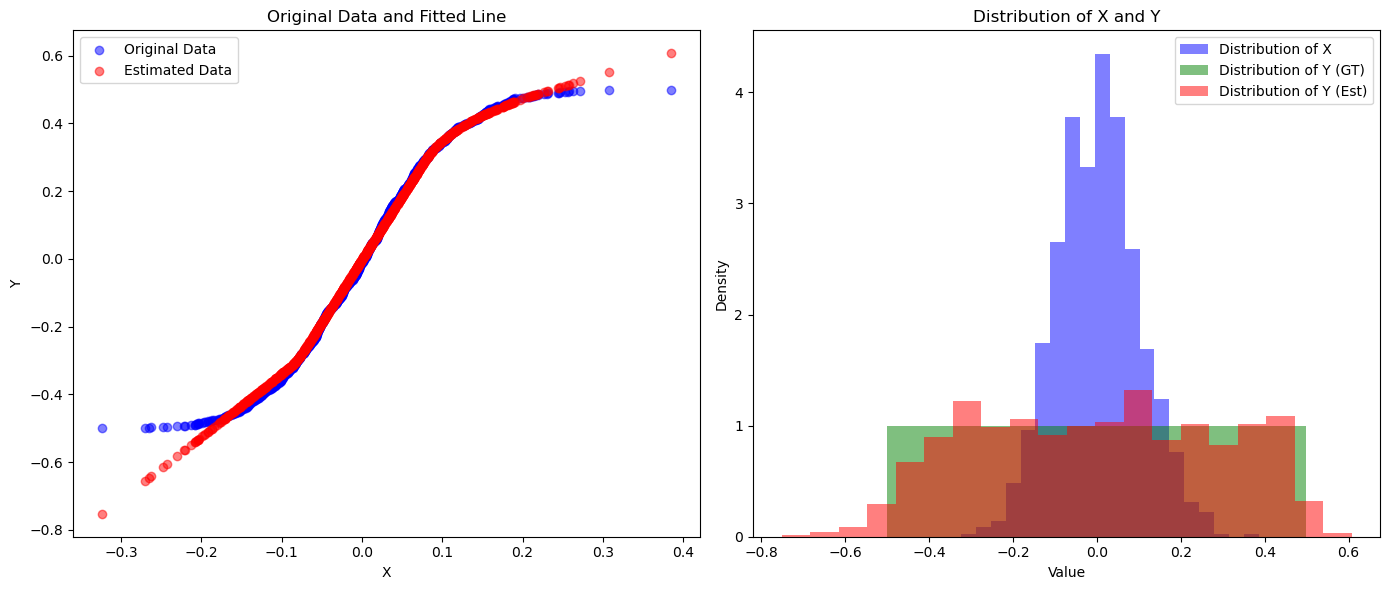

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Setting random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Generating Gaussian (Normal) Variable data for X
X = np.random.normal(loc=0, scale=0.1, size=(1000, 1)).astype(np.float32)  # mean=0, std=1
if 0:
    Y = np.random.uniform(low=-1, high=1, size=(1000, 1)).astype(np.float32)  # Y values clipped to be between -1 and 1
# Generating Uniform distribution for Y based on parameterized function of X
#Y = np.clip(10 * X + 1 + np.random.uniform(low=-1, high=1, size=(100, 1)), -10, 10).astype(np.float32)  # Y values clipped to be between -1 and 1
else:
    sorted_X = np.sort(X, axis=0)
    Y = [np.where(sorted_X == val)[0] for val in X]
    Y = np.array(Y).astype(np.float32) / len(X) - 0.5
    #Y += np.random.uniform(low=-0.1, high=0.1, size=(1000, 1)).astype(np.float32)
# Convert to Tensor
X_tensor = torch.from_numpy(X)
Y_tensor = torch.from_numpy(Y)

class DeepRegressor(nn.Module):
    def __init__(self):
        super(DeepRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),  # 1 input, 64 output
            nn.ReLU(),         # 활성화 함수
            nn.Linear(64, 128), # 64 input, 128 output
            nn.ReLU(),         # 활성화 함수
            nn.Linear(128, 64), # 128 input, 64 output
            nn.ReLU(),         # 활성화 함수
            nn.Linear(64, 1)   # 64 input, 1 output
        )

    def forward(self, x):
        return self.model(x)

# Setting up model, loss function and optimizer
model = DeepRegressor()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training the model
num_epochs = 10000
for epoch in range(num_epochs):
    model.train()
    
    # Passing input to the model
    optimizer.zero_grad()  # Reset gradients
    outputs = model(X_tensor)  # Calculate predictions
    loss = criterion(outputs, Y_tensor)  # Compute loss
    loss.backward()  # Compute gradients
    optimizer.step()  # Update model parameters
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Print the learned parameters of the model
for name, param in model.named_parameters():
    print(f'{name}: {param.data.numpy()}')

# Visualization of results
model.eval()
with torch.no_grad():
    predicted = model(X_tensor)

# Visualizing the distribution of X and Y
plt.figure(figsize=(14, 6))

# Original data and predicted results
plt.subplot(1, 2, 1)
plt.scatter(X, Y, label='Original Data', color='blue', alpha=0.5)
plt.scatter(X, predicted.numpy(), label='Estimated Data', color='red', alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original Data and Fitted Line')
plt.legend()

# Distribution of X and Y
plt.subplot(1, 2, 2)
plt.hist(X, bins=20, alpha=0.5, label='Distribution of X', color='blue', density=True)
plt.hist(Y, bins=20, alpha=0.5, label='Distribution of Y (GT)', color='green', density=True)
plt.hist(predicted.numpy(), bins=20, alpha=0.5, label='Distribution of Y (Est)', color='red', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of X and Y')
plt.legend()

plt.tight_layout()
plt.show()

Epoch [1000/10000], Loss: 3.9119
Epoch [2000/10000], Loss: 3.9118
Epoch [3000/10000], Loss: 3.9116
Epoch [4000/10000], Loss: 3.9114
Epoch [5000/10000], Loss: 3.9113
Epoch [6000/10000], Loss: 3.9111
Epoch [7000/10000], Loss: 3.9109
Epoch [8000/10000], Loss: 3.9107
Epoch [9000/10000], Loss: 3.9105
Epoch [10000/10000], Loss: 3.9103
model.0.weight: [[ 0.76456255]
 [ 0.8300079 ]
 [-0.23380715]
 [ 0.9186113 ]
 [-0.21910357]
 [ 0.20179069]
 [-0.48689762]
 [ 0.5864873 ]
 [ 0.8811364 ]
 [-0.73362815]
 [ 0.8691962 ]
 [ 0.1871593 ]
 [ 0.7388089 ]
 [ 0.13455531]
 [ 0.4821881 ]
 [-0.14077374]
 [ 0.7708858 ]
 [ 0.14780891]
 [-0.46630222]
 [ 0.2548983 ]
 [-0.4605787 ]
 [-0.11727285]
 [-0.40613264]
 [ 0.66337097]
 [-0.7893702 ]
 [-0.46223912]
 [-0.28227234]
 [-0.60127246]
 [ 0.09481681]
 [-0.9878437 ]
 [ 0.9031091 ]
 [-0.84946823]
 [ 0.7714313 ]
 [ 0.16641915]
 [-0.32470453]
 [ 0.61794996]
 [ 0.15585077]
 [ 0.8073673 ]
 [ 0.10931969]
 [-0.31537318]
 [ 0.2686883 ]
 [-0.27117944]
 [ 0.42085755]
 [ 0.892

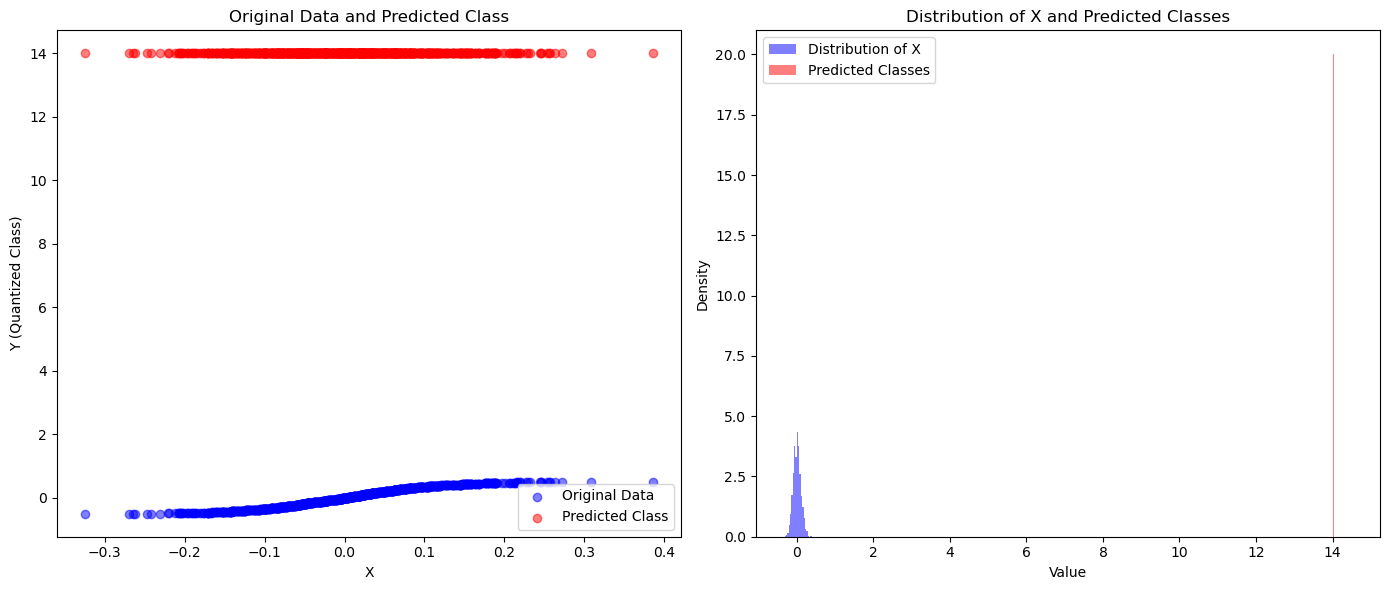

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Setting random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Quantization of Y into 50 discrete values
num_quantization_levels = 50
Y_quantized = np.clip(Y, -1, 1)  # Clip to ensure in range
quantization_bins = np.linspace(-1, 1, num_quantization_levels)  # Create quantization bins
Y_quantized = np.digitize(Y_quantized, quantization_bins) - 1  # Convert to quantization levels (0 to 49)
Y_quantized = Y_quantized.astype(np.float32)  # Convert back to float32 for consistency

# Convert to Tensor
X_tensor = torch.from_numpy(X)
Y_tensor = torch.from_numpy(Y_quantized)  # Use quantized labels

# Define a deep regressor as a classifier
class DeepClassifier(nn.Module):
    def __init__(self):
        super(DeepClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),  # 1 input, 64 output
            nn.ReLU(),         # Activation function
            nn.Linear(64, 128), # 64 input, 128 output
            nn.ReLU(),         # Activation function
            nn.Linear(128, 64), # 128 input, 64 output
            nn.ReLU(),         # Activation function
            nn.Linear(64, num_quantization_levels),   # 64 input, 50 output (for quantized classification)
            nn.Softmax(dim=1)   # Softmax activation
        )

    def forward(self, x):
        return self.model(x)

# Set up model, loss function, and optimizer
model = DeepClassifier()
criterion = nn.CrossEntropyLoss()  # Use cross-entropy loss for classification
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training the model
num_epochs = 10000
for epoch in range(num_epochs):
    model.train()

    # Passing input to the model
    optimizer.zero_grad()  # Reset gradients
    outputs = model(X_tensor)  # Calculate predictions
    loss = criterion(outputs, Y_tensor.long().view(-1))  # Compute loss
    loss.backward()  # Compute gradients
    optimizer.step()  # Update model parameters

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Print the learned parameters of the model
for name, param in model.named_parameters():
    print(f'{name}: {param.data.numpy()}')

# Visualization of results
model.eval()
with torch.no_grad():
    predicted = model(X_tensor)
    predicted_classes = torch.argmax(predicted, dim=1).numpy()

# Visualizing the distribution of X and the predicted classes
plt.figure(figsize=(14, 6))

# Original data and predicted results
plt.subplot(1, 2, 1)
plt.scatter(X, Y, label='Original Data', color='blue', alpha=0.5)
plt.scatter(X, predicted_classes, label='Predicted Class', color='red', alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y (Quantized Class)')
plt.title('Original Data and Predicted Class')
plt.legend()

# Distribution of X and Predictions
plt.subplot(1, 2, 2)
plt.hist(X, bins=20, alpha=0.5, label='Distribution of X', color='blue', density=True)
plt.hist(predicted_classes, bins=20, alpha=0.5, label='Predicted Classes', color='red', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of X and Predicted Classes')
plt.legend()

plt.tight_layout()
plt.show()